# import libraries 

In [1]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# load dataset and perform operations 

In [2]:

df = pd.read_csv("ai-adoption-fortune500-synthetic-dataset-2020-2025.csv", delimiter=',')

print("df: ", df)
print("df.head():  ", df.head())
print("df.info() : ", df.info())
print("df.describe(): ", df.describe())
print("df.shape:  ", df.shape)
print("df.columns: ", df.columns)
df.isnull().sum()


df:        Year             Company    Industry Country Company_Type Employee_Size  \
0     2020              Amazon  E-commerce     USA         Real    Enterprise   
1     2021              Amazon  E-commerce     USA         Real    Enterprise   
2     2022              Amazon  E-commerce     USA         Real    Enterprise   
3     2023              Amazon  E-commerce     USA         Real    Enterprise   
4     2024              Amazon  E-commerce     USA         Real    Enterprise   
...    ...                 ...         ...     ...          ...           ...   
5995  2021  SyntheticCorp_0980     Telecom  Brazil    Synthetic    Enterprise   
5996  2022  SyntheticCorp_0980     Finance   India    Synthetic           SME   
5997  2023  SyntheticCorp_0980  Technology  Canada    Synthetic    Enterprise   
5998  2024  SyntheticCorp_0980   Logistics     UAE    Synthetic    Enterprise   
5999  2025  SyntheticCorp_0980  Healthcare   Japan    Synthetic           SME   

       Revenue_USD Use

Year                    0
Company                 0
Industry                0
Country                 0
Company_Type            0
Employee_Size           0
Revenue_USD             0
Uses_AI                 0
Use_Case             1152
AI_ROI_Percent          0
AI_Maturity_Score       0
dtype: int64

# Numpy Operations

In [4]:
# Basic Statistics
Revenue_USD = df['Revenue_USD']

print("Mean Revenue:", np.mean(Revenue_USD))
print("Median Revenue:", np.median(Revenue_USD))
print("Maximum Revenue:", np.max(Revenue_USD))
print("Minimum Revenue:", np.min(Revenue_USD))
print("Standard Deviation:", np.std(Revenue_USD))

Mean Revenue: 15371103283.516914
Median Revenue: 42556664.120000005
Maximum Revenue: 494997560748.84
Minimum Revenue: 1010367.79
Standard Deviation: 43998149315.9982


# Seaborn Graphs

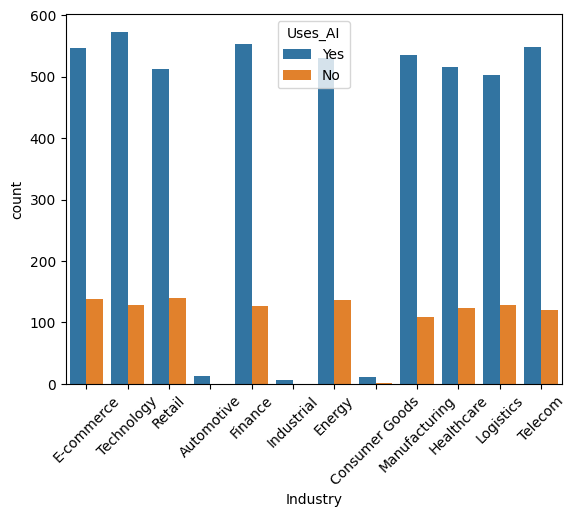

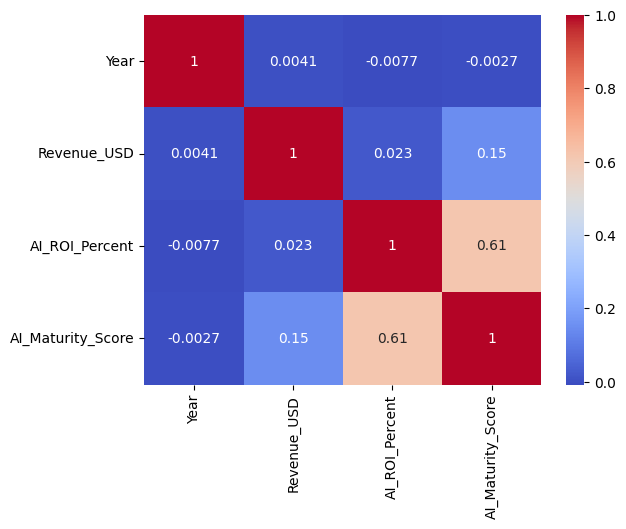

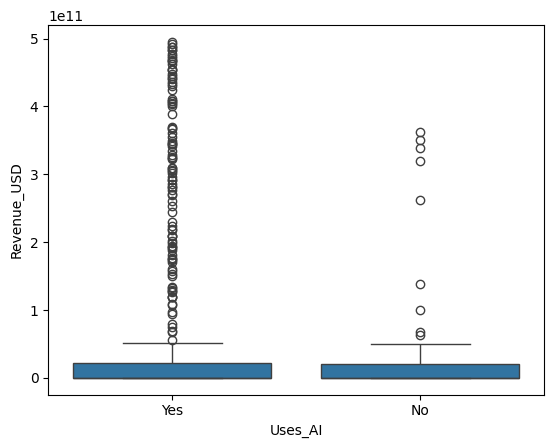

In [ ]:
#countplot top check which industry uses AI more
sns.countplot(x='Industry', hue='Uses_AI', data=df)
plt.xticks(rotation=45)
plt.show()

#heatmap to check the Correlation 
sns.heatmap(df.corr(numeric_only=True), annot=True, cmap='coolwarm')
plt.show()

#boxplot to show the numerical feature vs target column
sns.boxplot(x='Uses_AI', y='Revenue_USD', data=df)
plt.show()

# Feature Selection

In [6]:
cols_to_drop = ['Use_Case', 'Company_Type', 'Employee_Size','Company', 'Country','AI_ROI_Percent', 'AI_Maturity_Score']
df = df.drop(columns= cols_to_drop, errors='ignore')

X = df[['Year', 'Revenue_USD']]
y = df['Uses_AI']

print("X:", X)
print("y:", y)

X:       Year   Revenue_USD
0     2020  4.535464e+11
1     2021  4.878035e+11
2     2022  2.182500e+11
3     2023  4.114132e+11
4     2024  3.191970e+11
...    ...           ...
5995  2021  1.398673e+10
5996  2022  2.847901e+07
5997  2023  3.516618e+10
5998  2024  2.835842e+10
5999  2025  1.678214e+07

[6000 rows x 2 columns]
y: 0       Yes
1       Yes
2       Yes
3       Yes
4        No
       ... 
5995     No
5996    Yes
5997     No
5998    Yes
5999    Yes
Name: Uses_AI, Length: 6000, dtype: object


# Train Test Split Function 

In [7]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split( X, y,test_size=0.2, random_state=42,stratify=y)

from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)


from sklearn.svm import SVC

svm = SVC(kernel='rbf', class_weight='balanced')
svm.fit(X_train, y_train)
svm_preds = svm.predict(X_test)

from sklearn.metrics import classification_report,accuracy_score

print("SVM Accuracy:", accuracy_score(y_test, svm_preds))
print(classification_report(y_test, svm_preds))


from sklearn.neighbors import KNeighborsClassifier

knn = KNeighborsClassifier(n_neighbors=5)
knn.fit(X_train, y_train)
knn_preds = knn.predict(X_test)

from sklearn.metrics import accuracy_score, classification_report
print("KNN Accuracy:", accuracy_score(y_test, knn_preds))
print(classification_report(y_test, knn_preds))



SVM Accuracy: 0.4575
              precision    recall  f1-score   support

          No       0.19      0.57      0.29       230
         Yes       0.81      0.43      0.56       970

    accuracy                           0.46      1200
   macro avg       0.50      0.50      0.42      1200
weighted avg       0.69      0.46      0.51      1200

KNN Accuracy: 0.7825
              precision    recall  f1-score   support

          No       0.20      0.04      0.07       230
         Yes       0.81      0.96      0.88       970

    accuracy                           0.78      1200
   macro avg       0.50      0.50      0.47      1200
weighted avg       0.69      0.78      0.72      1200



# Analysis



In [ ]:
# Year and Revenue_USD are synthetic features with very weak
# relationship to the target variable (Uses_AI).
# Therefore, they provide limited predictive information.

# SVM achieved only 45% accuracy, indicating poor classification
# performance with these features.

# KNN achieved 78% accuracy, but this result may be influenced by
# class imbalance, as the model tended to predict the majority class.

# Overall, Year and Revenue_USD alone are not sufficient features
# for accurately predicting AI adoption.

# Measure Performance

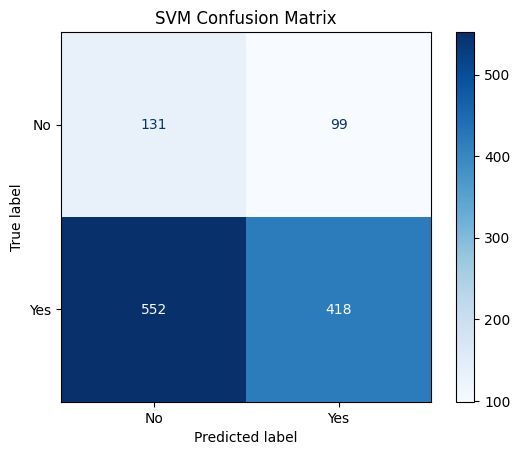

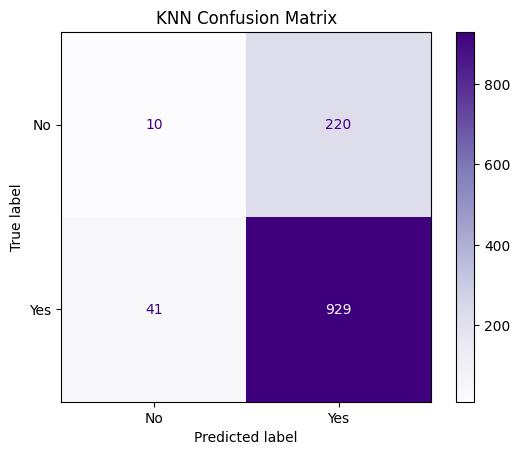

In [27]:
from sklearn.metrics import ConfusionMatrixDisplay, confusion_matrix
import matplotlib.pyplot as plt

# SVM Confusion Matrix
cm_svm = confusion_matrix(y_test, svm_preds)
disp_svm = ConfusionMatrixDisplay(confusion_matrix=cm_svm, display_labels=['No', 'Yes'])
disp_svm.plot(cmap='Blues')
plt.title('SVM Confusion Matrix')
plt.show()

# KNN Confusion Matrix
cm_knn = confusion_matrix(y_test, knn_preds)
disp_knn = ConfusionMatrixDisplay(confusion_matrix=cm_knn, display_labels=['No', 'Yes'])
disp_knn.plot(cmap='Purples')
plt.title('KNN Confusion Matrix')
plt.show()